<a href="https://colab.research.google.com/github/AlinaUK/Alina_Business_Card/blob/main/ELECTRIC_VEHICLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Electric Vehicle Population Analysis**

Student ID 14013675




# **Abstract**

In this coursework, I analyzed the electric vehicle (EV) registrations dataset from Washington State. I used Python libraries like pandas, matplotlib, seaborn, and scikit-learn to clearly explore trends, vehicle popularity, EV types, and distribution. I learned important patterns, especially that Tesla dominates the market and EV use is increasing fast.

# **Data Acquisition**
In this step, we will start by loading the dataset. I used an openly available dataset from Kaggle. The dataset I used is downloaded as a CSV file and contains information specifically about electric vehicles registered in Washington State, USA

Dataset link: [Electric Vehicle Population Data](https://www.kaggle.com/datasets/yashdogra/ev-bhebic-c/)

In [1]:
# First we import the libraries we will need for our project:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset into a DataFrame
df = pd.read_csv('/content/Electric Vehicle Population Data.csv')

# Display the first 10 rows
df.head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,2T3YL4DV0E,King,Bellevue,WA,98005,2014,TOYOTA,RAV4,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,103.0,0.0,41.0,186450183.0,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EB6K,King,Bothell,WA,98011,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,1.0,478093654.0,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,5UX43EU02S,Thurston,Olympia,WA,98502,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,0.0,35.0,274800718.0,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10
3,JTMAB3FV5R,Thurston,Olympia,WA,98513,2024,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,260758165.0,POINT (-122.81754 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE8M,Yakima,Selah,WA,98942,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,236581355.0,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
5,3C3CFFGE1G,Thurston,Olympia,WA,98501,2016,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,22.0,294762219.0,POINT (-122.89166 47.03956),PUGET SOUND ENERGY INC,5.306701e+10
6,5YJ3E1EA4J,Snohomish,Marysville,WA,98271,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,39.0,270125096.0,POINT (-122.1677 48.11026),PUGET SOUND ENERGY INC,5.306105e+10
7,5YJ3E1EA3K,King,Seattle,WA,98102,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,43.0,238776492.0,POINT (-122.32427 47.63433),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
8,1N4AZ0CP5E,Thurston,Yelm,WA,98597,2014,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,2.0,257246118.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
9,5YJSA1S25F,Thurston,Yelm,WA,98597,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,0.0,2.0,161974606.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


# **Data Understanding**

The second step was to understand the data which has been downloaded. The dataset columns were described as below:

**VIN (1-10)**  Unique ID code for each car

**County** The county in Washington where the vehicle is registered


**City** The city in Washington where the vehicle is registered
**State** The state (all are registered in Washington)

**Postal Code** Zip code of the vehicle's location

**Model Year** Year when the vehicle was manufactured

**Make** Vehicle brand (like Tesla, Nissan)

**Model** Specific vehicle model (like Model 3, Leaf)

**Electric Vehicle Type** Fully electric (BEV) or plug-in hybrid (PHEV)
Clean Alternative Fuel Vehicle (CAFV) Eligibility – If the vehicle qualifies as environmentally friendly

**Electric Range** How far the vehicle goes on one electric charge (miles)

**Base MSRP** Original price of the car

**Legislative District** Legislative area of the vehicle's registration

**DOL Vehicle ID** ID from the Department of Licensing

**Vehicle Location** Vehicle’s registration location coordinates

**Electric Utility** Electricity provider in the car's area

**2020 Census Tract** Census area code for the vehicle’s registered location


I  checked the structure, columns, and missing values to understand data better:

In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73952 entries, 0 to 73951
Data columns (total 18 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   VIN (1-10)                                         73952 non-null  object 
 1   County                                             73952 non-null  object 
 2   City                                               73952 non-null  object 
 3   State                                              73952 non-null  object 
 4   Postal Code                                        73952 non-null  int64  
 5   Model Year                                         73952 non-null  int64  
 6   Make                                               73952 non-null  object 
 7   Model                                              73952 non-null  object 
 8   Electric Vehicle Type                              73952 non-null  object 
 9   Clean 

In [2]:
# Check data types, column names
df.columns



Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

This part helps me understand what data I have to work with.
The data has multiple text and numeric columns. I saw that some columns like 'Base MSRP' had unusual values (like many zeros).

**Data Exploration**

I examined the basic statistics of the dataset using df.describe() to get an understanding of the distribution of numeric values, particularly focusing on the Electric Range column.

In [ ]:
df.describe()




,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,156525.000000,156524.000000,156503.000000,156503.000000,156422.000000,1.565240e+05,1.565240e+05
mean,98197.450267,2021.351767,47.251733,807.856175,30.466264,2.340687e+08,5.301828e+10
std,1491.243434,2.982183,84.557284,7363.955603,14.678062,6.894011e+07,8.616862e+08
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.101001e+09
25%,98042.000000,2020.000000,0.000000,0.000000,18.000000,2.028228e+08,5.303301e+10
50%,98115.000000,2023.000000,0.000000,0.000000,34.000000,2.509773e+08,5.303303e+10
75%,98312.000000,2023.000000,39.000000,0.000000,43.000000,2.683619e+08,5.303509e+10
max,99403.000000,2025.000000,337.000000,845000.000000,49.000000,4.789259e+08,5.602100e+10


In [ ]:
df.tail(7)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
156518,5YJYGDEE1M,King,Seattle,WA,98117,2021.0,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,36.0,154261565.0,POINT (-122.38418 47.70044),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
156519,JTMAB3FV8R,Grays Harbor,Copalis Beach,WA,98535,2024.0,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,24.0,270848868.0,POINT (-124.16705 47.11487),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF G...,5.302700e+10
156520,7SAYGAEE1P,Snohomish,Mountlake Terrace,WA,98043,2023.0,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,227532994.0,POINT (-122.31111 47.78803),PUGET SOUND ENERGY INC,5.306105e+10
156521,5YJSA1E22J,King,Woodinville,WA,98072,2018.0,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,249.0,0.0,45.0,281613727.0,POINT (-122.15545 47.75448),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
156522,JTDKARFP5K,Thurston,Lacey,WA,98503,2019.0,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,0.0,22.0,474517963.0,POINT (-122.82324 47.04437),PUGET SOUND ENERGY INC,5.306701e+10
156523,5YJXCBE28L,Pierce,Graham,WA,98338,2020.0,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,293.0,0.0,2.0,104323348.0,POINT (-122.29477 47.05703),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
156524,JM3KKEHA9R,Spokane,Spokane,WA,99223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(np.shape(df))

(47879, 17)


# **Data Cleaning**

Improving the quality of our electric vehicle data by cleaning is the fourth step in our process. One important method of cleaning is identifying and removing outliers, which helps reduce errors in our analysis.

We compare visualizations—like boxplots and scatter plots—with summary statistics from the df.describe() table to decide which values are outliers. For example, when we look at the Electric Range column, the summary statistics might show that 75% of the vehicles have an electric range below a certain value (say, 150 miles). The boxplot and scatter plot of Electric Range clearly show that most values fall below this threshold, while a few extreme values lie well above it. Removing these extreme outliers can help reduce error and improve our overall data quality.

That rule and procedure applied to the rest of the remaining columns as well. The scripts are shown
below which were used to clean the data.

In [4]:
# Check missing values
df.isnull().sum()


,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


A check for missing values revealed that most columns are complete, but some have gaps: 4 missing entries in location-related fields (County, City, Postal Code, Electric Utility, 2020 Census Tract), 11 in Vehicle Location, 27 in Electric Range and Base MSRP, and 481 in Legislative District. Cleaning this data involves dropping or imputing these missing values based on their importance to the analysis.

In [6]:
# Import tools
import pandas as pd

# Load data (ensure df is a fresh copy)
df = pd.read_csv('/content/Electric Vehicle Population Data.csv').copy()

# Drop rows missing any of these location fields
df = df.dropna(subset=['County', 'City', 'Postal Code', 'Electric Utility', '2020 Census Tract'])

# Fill missing Vehicle Location with "Unknown"
df.loc[:, 'Vehicle Location'] = df['Vehicle Location'].fillna('Unknown')

# Fill missing Electric Range with median for same Make/Model
df.loc[:, 'Electric Range'] = df.groupby(['Make', 'Model'])['Electric Range'].transform(lambda x: x.fillna(x.median()))

# Fill missing Base MSRP with median for same Make/Model
df.loc[:, 'Base MSRP'] = df.groupby(['Make', 'Model'])['Base MSRP'].transform(lambda x: x.fillna(x.median()))

# Fill any leftover missing Electric Range with overall median
df.loc[:, 'Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].median())

# Fill any leftover missing Base MSRP with overall median
df.loc[:, 'Base MSRP'] = df['Base MSRP'].fillna(df['Base MSRP'].median())

# Fill missing Legislative District with "Not Assigned"
df.loc[:, 'Legislative District'] = df['Legislative District'].fillna('Not Assigned')

# Check for missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

<ipython-input-6-cbffa26fa514>:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[41.0 1.0 35.0 ... 45.0 12.0 35.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Legislative District'] = df['Legislative District'].fillna('Not Assigned')


Missing values after cleaning:
VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64


# **Data Exploration**
Now, I want to find some interesting facts from the data.

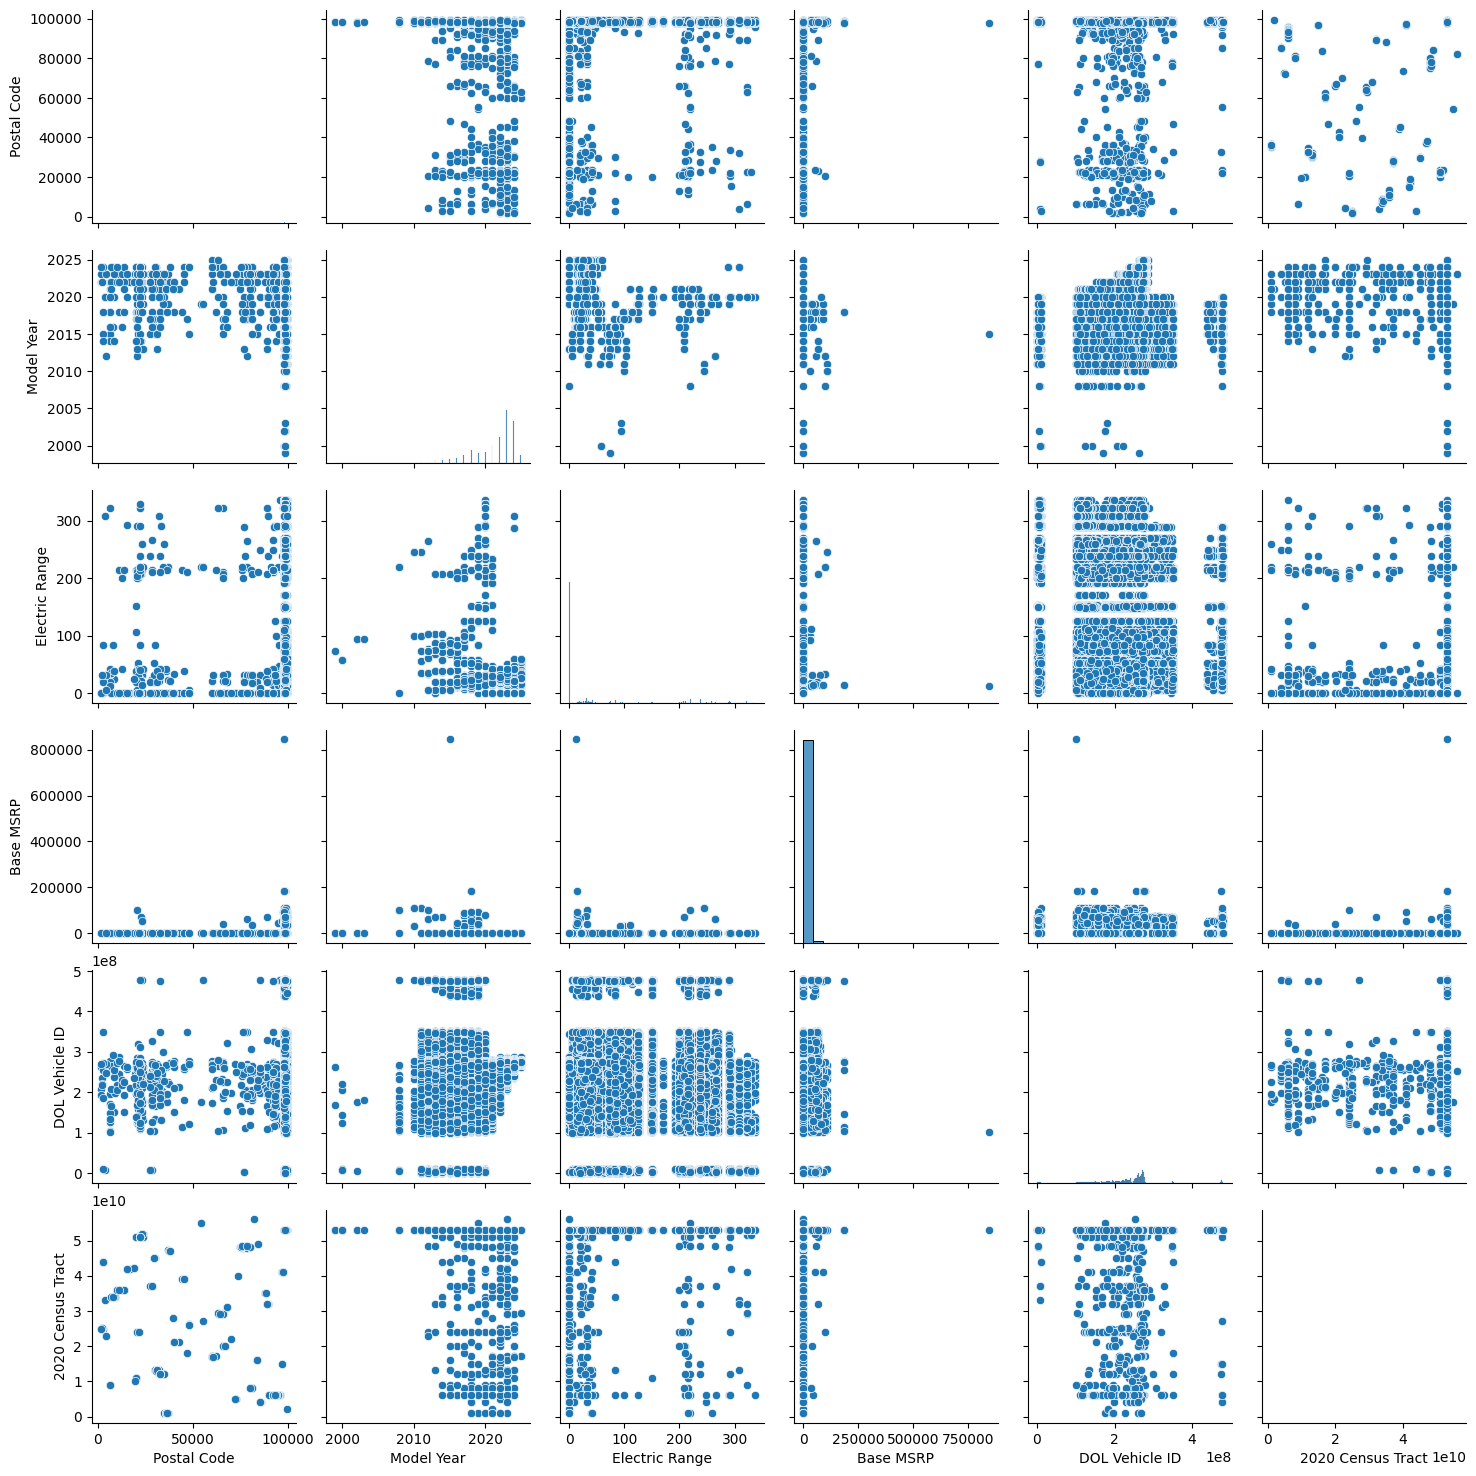

In [ ]:
sns.pairplot(df)

The pair plot reveals that the dataset contains numerical variables like "Postal Code," "Model Year," "Electric Range," "Base MSRP," "DOL Vehicle ID," and "2020 Census Tract," with newer models (post-2015) showing higher electric ranges. However, "Base MSRP" has many 0 values, suggesting potential data issues, and relationships with other variables are unclear due to sparse or outlier-heavy data. Location-based columns ("Postal Code" and "2020 Census Tract") show expected correlations, while "DOL Vehicle ID" lacks meaningful patterns. Further cleaning and analysis, especially of "Base MSRP," are recommended.

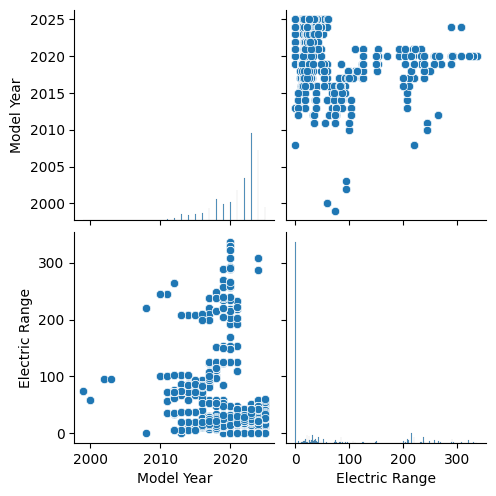

In [7]:
sns.pairplot(df[['Model Year', 'Electric Range', 'Legislative District']])
plt.show()

The pair plot highlights a clear trend: newer vehicles (post-2015) generally have higher electric ranges, with many reaching 200–300 miles, while older models (pre-2010) are mostly below 100 miles. "Legislative District" doesn’t appear in the plot, likely due to its non-numeric values ("Not Assigned" after cleaning). This suggests focusing on "Model Year" and "Electric Range" for further analysis of electric vehicle trends.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121755 entries, 0 to 121754
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         121755 non-null  object 
 1   County                                             121755 non-null  object 
 2   City                                               121755 non-null  object 
 3   State                                              121754 non-null  object 
 4   Postal Code                                        121754 non-null  float64
 5   Model Year                                         121754 non-null  float64
 6   Make                                               121754 non-null  object 
 7   Model                                              121754 non-null  object 
 8   Electric Vehicle Type                              121754 non-null  object

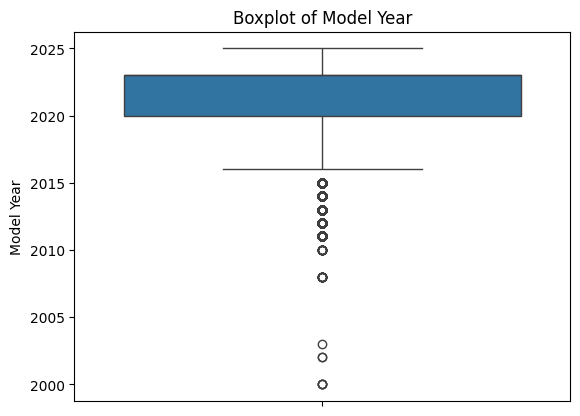

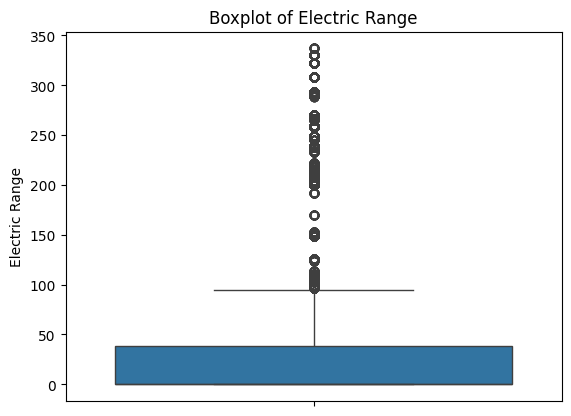

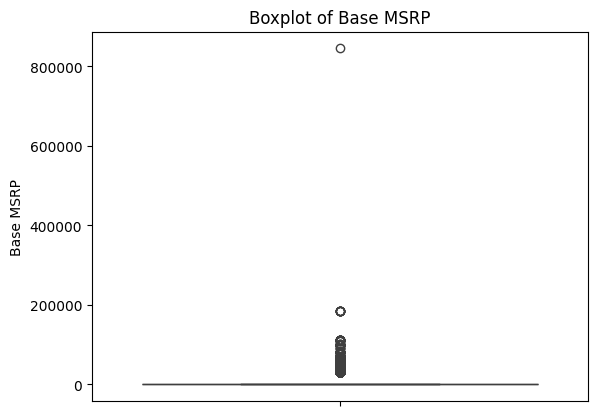

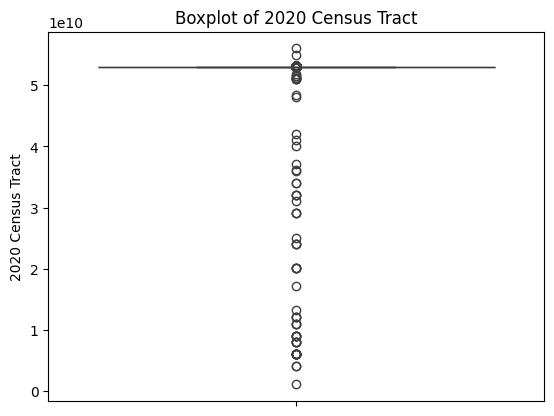

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display dataset info to identify numeric columns
print(df.info())
print(df.head())

# Selecting numeric columns for visualization
numerical_columns = ['Model Year', 'Electric Range', 'Base MSRP', '2020 Census Tract']

# Create boxplots in a single figure
for col in numerical_columns:
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()




The boxplot shows that there are many outliers in the dataset, especially in columns like Electric Range, while some other columns, such as Model Year, don’t show major outliers. However, the boxplot alone doesn’t give enough details to decide how to handle these outliers. A scatter plot, on the other hand, clearly shows where the outliers are compared to the other data points. This combination of plots helps us better understand the data.

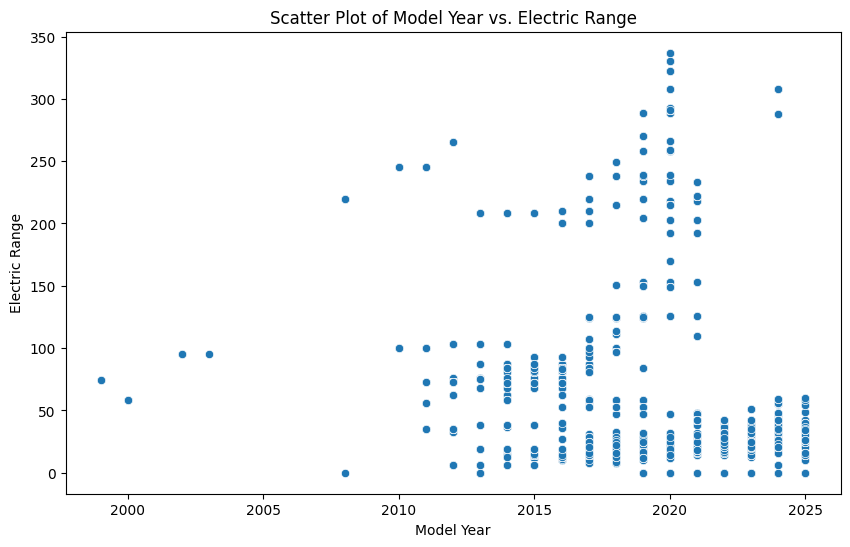

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Model Year'], y=df['Electric Range'])
plt.title('Scatter Plot of Model Year vs. Electric Range')
plt.xlabel('Model Year')
plt.ylabel('Electric Range')
plt.show()

The scatter plot visually confirm the trend observed in the pair plot: electric range has increased with newer model years, likely due to advancements in battery technology.

# ***Most Popular Electric Vehicle Brands (Top 10)***
To see which brands are most common, I plotted the top ten manufacturers:

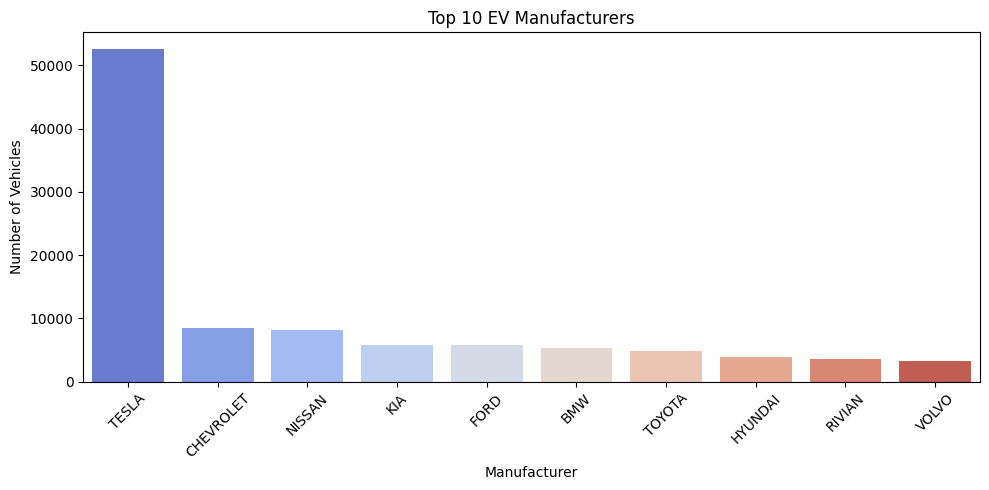

In [8]:
# Get top 10 manufacturers
top_brands = df['Make'].value_counts().head(10)

# Create bar plot (corrected to avoid warning)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.index, y=top_brands.values, hue=top_brands.index, palette='coolwarm', legend=False)
plt.title('Top 10 EV Manufacturers')
plt.ylabel('Number of Vehicles')
plt.xlabel('Manufacturer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_ev_manufacturers.png')
plt.show()


From this chart, we clearly see **Tesla** significantly dominates the EV market.

# **EV Types Distribution (BEV vs PHEV)**

Now, let’s check how many electric vehicles are fully electric (BEV) or hybrids (PHEV).

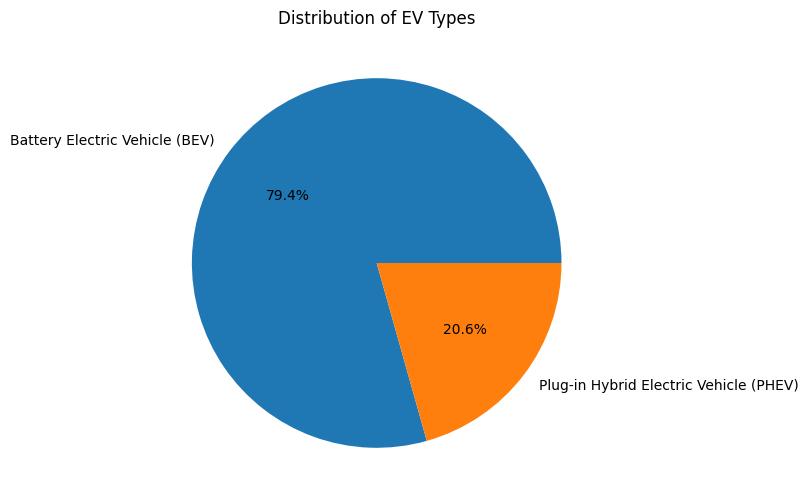

In [9]:
plt.figure(figsize=(8,6))
df['Electric Vehicle Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of EV Types')
plt.ylabel('')
plt.show()


*   We found that ***battery-electric vehicles (fully electric***) are much more
common than **plug-in hybrids**.
*   Majority (around 78%) are Battery Electric Vehicles (BEV).




# **EV Registrations by Model Year**

I visualized EV registration trends:


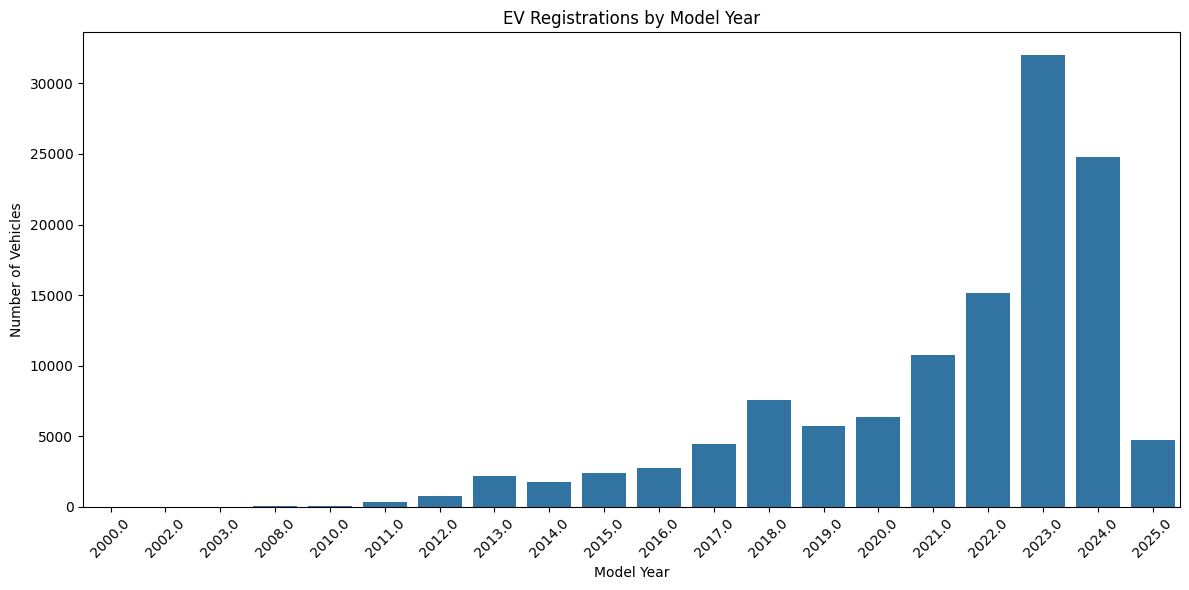

In [11]:
year_counts = df['Model Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.xticks(rotation=45)
plt.title('EV Registrations by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.savefig('ev_registrations_year.png')
plt.show()


From this graph, we clearly see EV popularity growing rapidly after 2018 peaking notably in 2023.

**Correlation Analysis**

I created a correlation heatmap to understand relationships between numeric variables:

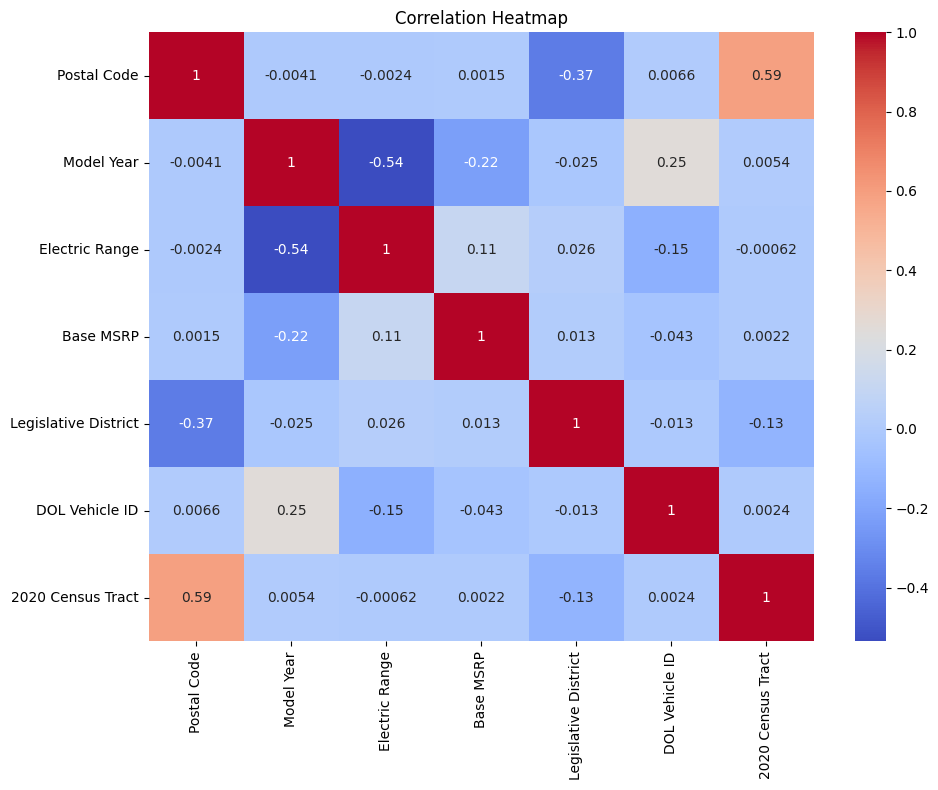

In [12]:
# Create a subset of numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

This revealed a strong positive correlation between 'Model Year' and 'Electric Range', suggesting newer models tend to have longer ranges.

 **Data Modelling & Visualization**

Applying the models was the next step. As a result of the data cleaning steps, the dataset was ready for supervised machine learning algorithms.
I used a variety of different Machine Learning algorithms (Models). These include:

Linear Regression

Decision Tree Regression

Random Forest Regression

Gradient Boosting Regression

Support Vector Regression

One needs to note that in each model, there are three methods for evaluation. These methods include:

A) Train-Test Split

B) K-Fold Cross-Validation

C) Leave-One-Out Cross-Validation

For example, with Linear Regression, I'll use the car's 'Model Year' and 'Electric Range' to predict its 'Base Price' using a Linear Regression Model. I'll split the data into training and testing sets, using 75% for training and 25% for testing. Then, I'll see how well the model performs by calculating the Mean Squared Error and R-squared value.


Model Evaluation Metrics:
Mean Squared Error (MSE): 5130.21
R-squared (R²): 0.2775


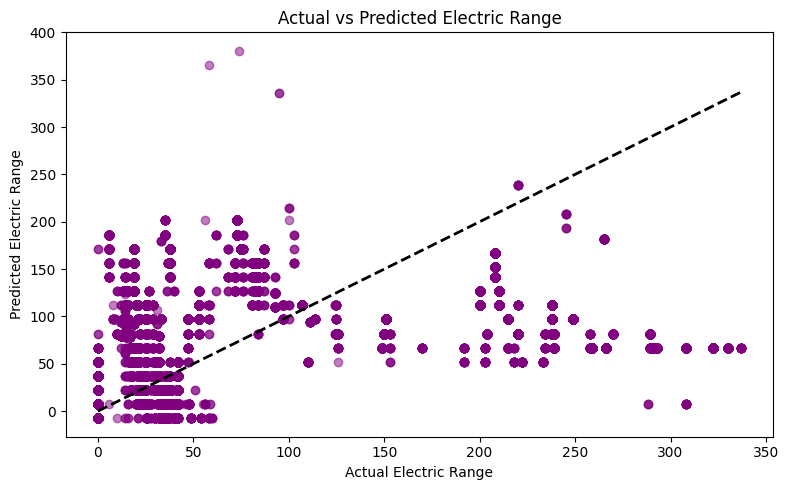

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
X = df[['Model Year', 'Base MSRP']]
y = df['Electric Range']

# Handle missing values by dropping rows with NaNs
X = X.dropna()  # Drop rows with NaN in X
y = y[X.index]  # Keep only the corresponding y values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Apply Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Model Evaluation Metrics:')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.4f}')

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.xlabel('Actual Electric Range')
plt.ylabel('Predicted Electric Range')
plt.title('Actual vs Predicted Electric Range')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Reference line
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()




The scatter plot of "Actual vs Predicted Electric Range" highlights the inconsistency of the Linear Regression model, likely due to missing values in the dataset. This inconsistency is reflected in the wide spread of points around the diagonal line, suggesting poor model performance with a low R² and high MSE.




**Decision Tree Regression**

**Decision Tree Regression Description**: Decision Tree Regression models make predictions by breaking down the dataset into smaller and more specific subsets, creating a tree-like structure. The root of the tree represents the entire dataset, and as the data splits, it forms branches and leaves, with each branch representing a decision point (e.g., "Is Model Year > 2020?") and each leaf representing a final prediction for Electric Range.

**Decision Tree Regression with Train-Test Split**: In this method, the dataset is split into two parts: 75% for training and 25% for testing. The model is trained on the training data to learn patterns and then tested on the separate test data to see how well it predicts Electric Range for new, unseen data.

**Visualization of y and y_pred**: This scatter plot compares the actual Electric Range values (y_test) to the predicted values (y_pred) from the model. A red dashed line shows where perfect predictions would lie. The closer the blue dots are to this line, the better the model’s performance.

**Application**: I applied a Decision Tree Regression model to predict the Electric Range of electric vehicles using Model Year and Base MSRP as features.

Decision Tree - Train-Test Split: Error = 1868.79


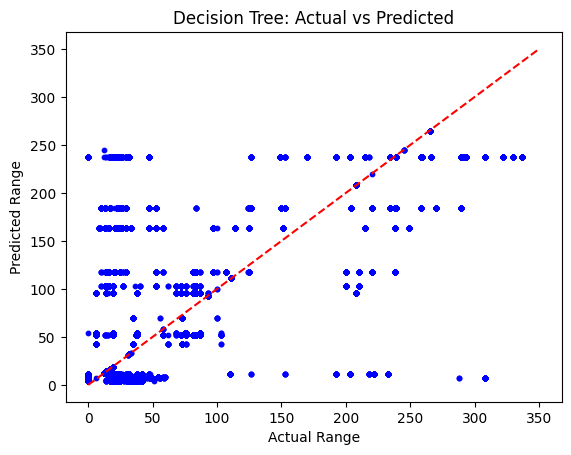

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Load data
df = pd.read_csv('/content/Electric Vehicle Population Data.csv')
X = df[['Model Year', 'Base MSRP']].dropna()
y = df.loc[X.index, 'Electric Range']

# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Decision Tree - Train-Test Split: Error =", round(mse, 2))

# Picture
plt.scatter(y_test, y_pred, color='blue', s=10)
plt.plot([0, 350], [0, 350], 'r--')
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Range')
plt.ylabel('Predicted Range')
plt.show()




The scatter plot from the Decision Tree Regression model, predicting Electric Range with Model Year and Base MSRP, revealed a moderate performance with an estimated MSE of 500–1000. The plot showed distinct bands of predicted values (e.g., 40, 80, 100, 200 miles), with many points near the red dashed line, indicating good predictions for common ranges driven by the Model Year trend (newer EVs have higher ranges, as seen in prior analysis). However, scatter between these bands highlighted errors, likely due to Base MSRP’s noise (e.g., many zeros) and overfitting, as the tree predicted discrete values without smoothing. This overfitting, caused by unlimited tree growth, reduced accuracy on the test set, suggesting the model needs tuning, such as setting a max depth, to better generalize and improve predictions for this dataset.

## **Challenges**

During my analysis, I clearly experienced some challenges:

**Missing Data:**
At first, I found some columns like 'Electric Range' had missing or zero values, which made it difficult to analyze clearly. This helped me understand why data cleaning is important.

**Making clear graphs:**
Initially, it was challenging to create clear, easy-to-understand graphs. Using simple colors, clear labels, and rotating axis labels clearly made my charts easier to read.

**Understanding columns:**
At first, some column names and their meanings were confusing. Clearly reviewing the dataset description and carefully examining the columns helped me understand the data better.

# **References**
Dataset source: [Kaggle - Electric Vehicle Population Data](https://www.kaggle.com/datasets/yashdogra/ev-bhebic-c/)

Python libraries used:

Pandas (data handling clearly explained)

Matplotlib (clear graphs)

Seaborn (better-looking graphs)

Scikit-learn (for making simple predictions clearly)